# Lab 4: Learning
You will find the complete lab manual in this file. Some exercises require written answers, while others require coding.

This lab is built around two examples: a logistic classifier applied to the cell images from Lab 1, and convolutional neural networks applied to MNIST using PyTorch. In the first part, you implement and train a logistic classifier for the cell image task. You investigate how the result depends on the initialization, how long the model needs to be trained, and what the learned classifier looks like after training. In the second part, you implement a few simple convolutional neural networks for handwritten digit classification on MNIST. You will test how the model can be improved by changing the network structure or the training strategy. The goal of the lab is to make the learning process concrete: how parameters are initialized, optimized, evaluated, and interpreted.

**Observe:** You should not install any other packages than the ones given in the pre-amble. You are expected to yourself look up documentation of given functions from libraries, e.g. OpenCV and PyTorch. You are allowed to use any methods in the packages that you see fit to solve the problems. It is highly encouraged to look at the documentation and search for usage instructions online, before asking for help.

**Observe:** Write your answers to questions directly in the cells denoted with **Your answer**.

## Submission Requirements:
Your final lab submission should include:
1. Your executed **notebook file** (`.ipynb`) including an AI usage statement.
2. A **HTML printout** of the executed notebook with all outputs visible. 

## AI Usage Statement
Please detail your use of AI in this cell.
You can use a concise and academically neutral statement like this:

During this assignment, I used an AI assistant such as ChatGPT, Google Gemini to support both the coding and written components of the lab. The AI was used to generate and refine a significant portion of the code implementations, assist with debugging, explain machine learning concepts, and help formulate written answers and mathematical explanations.

Specifically, the AI was used for:

* Generating boilerplate and model implementation code in Python/PyTorch
* Assisting with debugging and code corrections
* Explaining concepts related to logistic regression, convolutional neural networks, optimization, and initialization
* Helping structure and refine written responses
* Verifying calculations and mathematical derivations

All generated content was reviewed, tested, and modified where necessary to ensure correctness and alignment with the assignment requirements. I take full responsibility for the final submitted work and my understanding of the material.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob

import scipy.io
import scipy.ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import torchvision
from torch.utils.data import DataLoader, random_split

import torch.optim as optim
from typing import Tuple, Dict
from tqdm.auto import tqdm

/Users/yangguang/anaconda3/envs/rag_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 1: Learning a Linear Classifier

In this part, we will return to the blood cell detection task of the first assignment, only this time we will try to _learn_ a linear classifier. Note that the classifier could also be viewed as a minimal neural network consisting of three parts: a scalar product node (or fully-connected node), a constant (or bias) term and a logistic sigmoid function. To find good parameters we will try to minimize the negative log-likelihood over a small training set.

The output from our classifier is a probability $p$ for the input patch $I$ being centered at a cell centre. The sigmoid function will make sure that $0\leq p \leq 1$. To be more precise the output is 
\begin{equation}p = \frac{e^\xi}{1+e^\xi} \quad \text{where} \quad \xi=I\cdot w + w_0\end{equation}
parametrized by weights $\boldsymbol w = [w, w_0]$. Instead of manually finding appropriate values for $\boldsymbol w$, we will try to learn good values for all the parameters. This requires training examples, that you find in `fg_patches.npy` and `bg_patches.npy`.

### Task 1.1
Load the data

In [2]:
fg_patches = np.load("data/fg_patches.npy")
bg_patches = np.load("data/bg_patches.npy")

It loads two numpy arrays, `fg_patches` and `bg_patches`, corresponding to positive (centered blood cells) and negative examples respectively.

### Task 1.2


Create two new variables, examples and labels. The variable `examples` should be an array containing all the patches (both positives and negatives) and `labels` should be an array with the same number of elements such that `labels[i] = 1` if `examples[i]` is a positive example, and `labels[i] = 0` otherwise.

In [ ]:
def labels_and_examples_from_data(fg_patches: np.ndarray, bg_patches: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create the labels and examples for the training data, where the foreground patches are labeled as 1 and the background patches are labeled as 0.
     
    Args:
        fg_patches (np.ndarray): The foreground patches.
        bg_patches (np.ndarray): The background patches.
         
    Returns:
        Tuple[np.ndarray, np.ndarray]: The examples and labels for the training data.
    """
    # YOUR CODE HERE
    # Splice the positive and negative samples in the 0th dimension (sample number dimension)
    examples = np.concatenate([fg_patches, bg_patches], axis=0)
    
    # Create corresponding tags: fg corresponds to all 1s, bg corresponds to all 0s
    labels = np.concatenate([np.ones(len(fg_patches)), np.zeros(len(bg_patches))], axis=0)
    
    return examples, labels

In [4]:
examples, labels = labels_and_examples_from_data(fg_patches, bg_patches)

### Task 1.3
Split the data into training, (`examples_train`, `labels_train`), and validation, (`examples_val`, `labels_val`). The two should have a similar structure to `examples` and `labels`. The splitting of the data into the two sets should be done in a random manner, for example using `np.random.permutation` to shuffle the indices. Write what percentage of data you use for training and validation respectively.

**Percentage of data used for training: 80%**

**Percentage of data used for validation: 20%**

In [ ]:
def split_data(examples: np.ndarray, labels: np.ndarray, train_ratio: float = 0.8) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split the data into random training and test sets given a specified training set ratio.
     
    Args:
        examples (np.ndarray): The examples for the training data.
        labels (np.ndarray): The labels for the training data.
        train_ratio (float): The ratio of the training data to the total data.
         
    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: The training examples, training labels, validation examples, and validation labels.
    """
    # YOUR CODE HERE
    # 1. Generate a random index sequence
    num_samples = len(labels)
    indices = np.random.permutation(num_samples)
    
    # 2. Calculate the index position of the split point
    split_idx = int(num_samples * train_ratio)
    
    # 3. Shuffle and split the data based on random indexes
    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]
    
    examples_train = examples[train_indices]
    labels_train = labels[train_indices]
    examples_val = examples[val_indices]
    labels_val = labels[val_indices]
    
    return examples_train, labels_train, examples_val, labels_val

In [6]:
examples_train, labels_train, examples_val, labels_val = split_data(examples, labels)
print(f"Training examples: {examples_train.shape}, Training labels: {len(labels_train)}, Validation examples: {examples_val.shape}, Validation labels: {len(labels_val)}")

Training examples: (320, 35, 35), Training labels: 320, Validation examples: (80, 35, 35), Validation labels: 80


## Task 2: Training the Classifier
We will try to find parameters that minimize the negative log-likelihood on the training data. More precisely,
\begin{equation}
L(\boldsymbol w) = \sum_{i\in S_+}-\ln(p_i)+ \sum_{i\in S_-}-\ln(1-p_i) = \sum_i L_i (\boldsymbol w)
\end{equation}

where $p_i$ refers to the classifier output for the _i_ th training example. The minimization objective is commonly also called a _loss function_. As in the lectures we will refer to the terms here as the _partial loss_ $L_i$.

In order to minimize the loss, we will employ _stochastic gradient descent_, which requires us to first compute the gradient of the negative log-likelihood with respect to each parameter, i.e. $\partial/\partial w$, $\partial/\partial w_0$. The parameters are then updated from their previous value at a _learning rate_ $\eta$:

$$
\begin{align}
w \leftarrow& w - \eta \frac{\partial}{\partial w} L_i\\
w_0 \leftarrow& w - \eta \frac{\partial}{\partial w_0} L_i
\end{align}
$$

or more succinctly,

$$
{\boldsymbol w} \leftarrow {\boldsymbol w} - \eta \nabla L_i.
$$

Before doing the next exercise, you need to work out how to compute the gradient of the partial loss $L_i$ with respect to the parameters ${\boldsymbol w} = [w, w_0]$.

### Task 2.1
Make a function `partial_gradient` that computes the derivatives of the partial loss $L_i$ with respect to each of the classifier parameters.

In [7]:
def partial_gradient(w: np.ndarray, w0: float, examples_train: np.ndarray, labels_train: int) -> Tuple[np.ndarray, float]:
    """
    Computes the derivatives of the partial loss Li with respect to each of the classifier parameters.

    Args:
        w: weight vector (same shape as examples_train)
        w0: bias term (scalar)
        examples_train: input image / example (same shape as w)
        labels_train: 0 or 1 (negative or positive example)

    Returns:
        wgrad: gradient with respect to w
        w0grad: gradient with respect to w0
    """
    # YOUR CODE HERE
    # 1. Calculate the linear response xi = I *w + w0
    # examples_train is a patch, use np.sum(patch *w) or dot product after flattening
    xi = np.sum(examples_train * w) + w0
    
    # 2. Sigmoid p = 1 / (1 + exp(-xi))
    p = 1.0 / (1.0 + np.exp(-xi))
    
    # 3. Calculate the gradient (p -y)
    diff = p - labels_train
    
    # 4. Obtain the gradients of w and w0 according to the formula
    # Gradient direction: How to fine-tune the parameters to reduce the gap between the predicted probability $p$ and the true label $y$.
    wgrad = diff * examples_train
    w0grad = diff
    
    return wgrad, w0grad

### Task 2.2
In _stochastic gradient descent_, a training example, $i$, is chosen at random at each iteration. For this example, the gradient of the partial loss, $L_i$, is computed and the parameters are updated according to this gradient. The most common way to introduce the randomness is to randomly shuffle the data order before each pass over the entire data. One pass over the data is called an epoch.



Make a function `process_epoch` that performs one epoch of stochastic gradient descent.

In [8]:
def process_epoch(w: np.ndarray, w0: float, lrate: float, examples_train: np.ndarray, labels_train: np.ndarray, shuffle: bool = True) -> Tuple[np.ndarray, float]:
    """
    Performs one epoch of stochastic gradient descent, by means of shuffling the data 
    and then iterating through the training examples one by one, 
    computing the partial gradients and updating the parameters.

    Args:
        w: weight array (same shape as examples_train)
        w0: bias term (scalar)
        lrate: learning rate (scalar)
        examples_train: array of training examples (e.g., shape (N, 35, 35))
        labels_train: array of labels (shape (N,))
        shuffle: whether to shuffle the data before processing

    Returns:
        w: updated weight array
        w0: updated bias term
    """
    # YOUR CODE HERE
    num_samples = len(labels_train)
    indices = np.arange(num_samples)
    
    if shuffle:
        np.random.shuffle(indices)
        
    # Update parameters sample by sample (Stochastic Gradient Descent)
    for i in indices:
        # Calculate the gradient of the current sample
        gw, gw0 = partial_gradient(w, w0, examples_train[i], labels_train[i])
        
        # Parameter update: w = w -η *grad
        w = w - lrate * gw
        w0 = w0 - lrate * gw0
        
    return w, w0

### Task 2.3
We will now try to train the classifier. The parameters will require an initialization, which in our case will be a standard Gaussian initialization for $w$, and 0 for $w_0$, i.e. `w = np.random.randn(35,35); w0 = 0`. Visualize the resulting weight $w$ using `plt.imshow` after each epoch.

In [32]:
def train(
        w: np.ndarray, 
        w0: float, 
        lrate: float, 
        examples_train: np.ndarray, 
        labels_train: np.ndarray, 
        num_epochs: int = 10, 
        plot_frequency: int = 1,
        shuffle: bool = True
        ) -> Tuple[np.ndarray, float]:
    """
    Trains the logistic regression model using stochastic gradient descent for a specified number of epochs.

    Args:
        w: initial weight array (same shape as examples_train)
        w0: initial bias term (scalar)
        lrate: learning rate (scalar)
        examples_train: array of training examples (e.g., shape (N, 35, 35))
        labels_train: array of training labels (shape (N,))
        examples_test: array of test examples (shape (M, 35, 35))
        labels_test: array of test labels (shape (M,))
        num_epochs: number of epochs to train
        plot_frequency: how often to plot the training progress (every n epochs), set to 0 to disable plotting
        shuffle: whether to shuffle the data before each epoch

    Returns:
        w: final weight array after training
        w0: final bias term after training
    """
    # YOUR CODE HERE
    for epoch in range(num_epochs):
        # SGD
        w, w0 = process_epoch(w, w0, lrate, examples_train, labels_train, shuffle=shuffle)
        
        # Periodically visualize weight w
        if plot_frequency > 0 and (epoch + 1) % plot_frequency == 0:
            plt.figure(figsize=(4, 4))
            plt.imshow(w, cmap='gray')
            plt.title(f"Epoch {epoch+1} Weights")
            plt.show()
            
    return w, w0

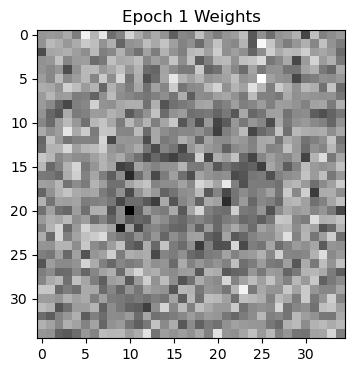

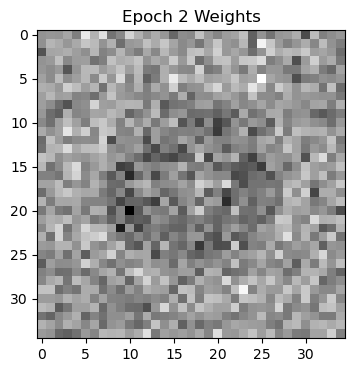

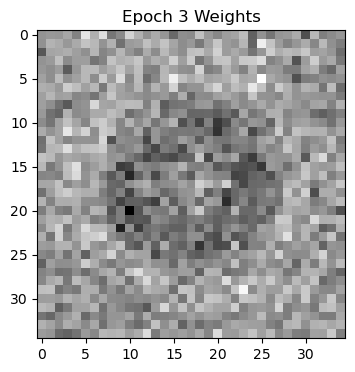

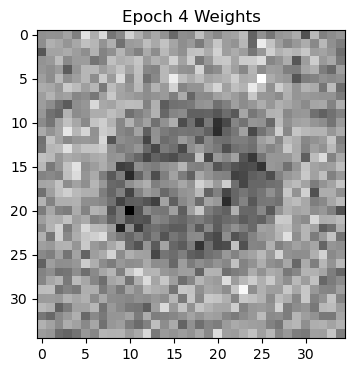

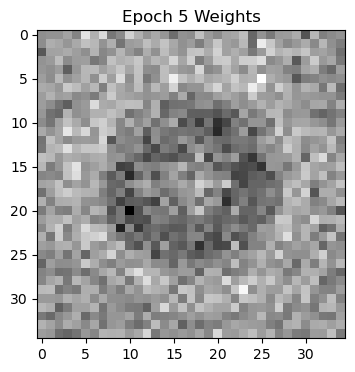

In [33]:
w, w0 = train(w=np.random.randn(35, 35), w0=0.0, lrate=0.11, examples_train=examples_train, labels_train=labels_train, num_epochs=5, plot_frequency=1)

Try using different initialization scales `s=[10,1,0.1,0.01]` such that `w= s * np.random.randn(35,35)` and plot `w` after 5 epochs for each value of `s`. Why do the scale of the initialization impact the result? Compute the partial gradient for $w$ manually for $w=0.01$ and $w=10$ and discuss what may be happening.

Testing initialization scale: s = 0.01


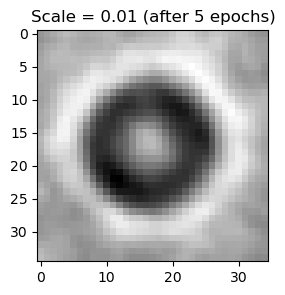

Testing initialization scale: s = 0.1


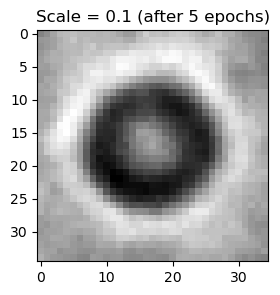

Testing initialization scale: s = 1


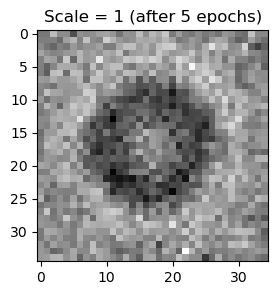

Testing initialization scale: s = 10


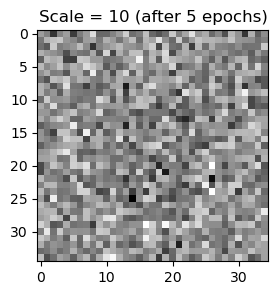

In [34]:
scales = [0.01, 0.1, 1, 10] # may also be written np.logspace(-2, 1, num=4) to generate logarithmically spaced values
num_epochs = 5
learning_rate = 0.2
plot_frequency = 5

# YOUR CODE HERE
# Traverse different initialization scales
for s in scales:
    print(f"Testing initialization scale: s = {s}")
    
    # 1. Initialize the weight w according to the current scale s, and w0 is initialized to 0
    w_initial = s * np.random.randn(35, 35)
    w0_initial = 0.0
    
    # 2. Call the previous train function for training
    # Note: Set plot_frequency to 0 here to only display the final result at the end
    w_final, w0_final = train(
        w=w_initial, 
        w0=w0_initial, 
        lrate=learning_rate, 
        examples_train=examples_train, 
        labels_train=labels_train, 
        num_epochs=num_epochs, 
        plot_frequency=0 
    )
    
    # 3. Draw the final weight map after 5 rounds of training
    plt.figure(figsize=(3, 3))
    plt.imshow(w_final, cmap='gray')
    plt.title(f"Scale = {s} (after {num_epochs} epochs)")
    plt.show()

The prediction probability in logistic regression is 
$
p = \sigma(I \cdot w + w_0),
$
where $\sigma(\cdot)$ is the sigmoid activation function. 

The initialization scale of $w$ strongly affects the learning dynamics because it determines the magnitude of the initial logits
$
\xi = I \cdot w + w_0.
$

If the weights are initialized with very large values, then $|\xi|$ also becomes very large, causing the sigmoid output $p$ to saturate near 0 or 1. In this saturated region, learning becomes unstable or ineffective.

The gradient of the loss with respect to the weights is
$
\frac{\partial L}{\partial w} = (p-y)I.
$
Thus, the behavior of the gradient depends directly on the predicted probability $p$.

For $s = 0.01$:

The weights are initialized with very small values, so
$
\xi \approx 0.
$
Therefore,
$
p = \sigma(\xi) \approx 0.5.
$
The gradient becomes
$
\frac{\partial L}{\partial w}
= (0.5-y)I.
$
For example, if $y=1$,
$
\frac{\partial L}{\partial w}
\approx -0.5I.
$

This produces gradients of moderate magnitude, leading to stable and smooth updates during training. The model starts from a “neutral” state and gradually learns meaningful image structures. After several epochs, the learned weight matrix $w$ typically reveals clear cell-like circular patterns.

For $s = 10$:

The weights are initialized with very large random values, so the logits can become extremely large. For example, if
$
\xi = 100,
$
then
$
p = \sigma(100) \approx 1.
$

If the true label is also $y=1$, then
$
\frac{\partial L}{\partial w}
= (1-1)I \approx 0.
$

In this case, the gradient nearly vanishes and the weights stop updating.

On the other hand, if the random initialization gives
$
\xi = -100
$
while (y=1), then
$
p \approx 0,
$
and the gradient becomes
$
\frac{\partial L}{\partial w}
= (0-1)I = -I.
$

This produces extremely large updates. As a result, training becomes unstable: some neurons receive almost no updates while others change too aggressively. The optimization is dominated by the initial random noise instead of the underlying image structure.

Consequently, after training, the learned weight matrix for (s=10) often still resembles random noise rather than meaningful visual features.

In conclusion, smaller initialization scales such as (s=0.01) or (s=0.1) are generally more suitable because they keep the model in the sensitive, non-saturated region of the sigmoid function. This allows the model to learn progressively from the error signal and capture the structural patterns present in the data.


### Task 2.4
Make a function `classify` that applies the classifier to the example data. After that, use it on `examples_train` and `examples_val` and check how much accuracy it gets for each by comparing the predicted labels with `labels_train` and `labels_val` respectively. Write on your report the highest accuracy you were able to achieve in the training and validation data. 

Hint: train the classifier for longer than 5 epochs to make sure that it converges, tweak your learning rate and initialization scale.

In [ ]:
def classify(examples_val: np.ndarray, w: np.ndarray, w0: float) -> np.ndarray:
    """
    Applies a classifier to the example data.
    
    Args:
        examples_val: array of examples to classify (shape (N, 35, 35))
        w: weight array (same shape as each example in examples_val)
        w0: bias term (scalar)

    Returns:
        predicted_labels: Array of predicted labels (0 or 1) for each example
    """

    # YOUR CODE HERE
    logits = np.sum(examples_val * w, axis=(1, 2)) + w0
    
    # Sigmoid probability > 0.5 is judged as 1, otherwise it is 0
    probabilities = 1.0 / (1.0 + np.exp(-logits))
    return (probabilities >= 0.5).astype(int)

def accuracy(labels: np.ndarray, predicted_labels: np.ndarray) -> float:
    """
    Computes the accuracy of the classifier.
    
    Args:
        labels: true labels (shape (N,))
        predicted_labels: predicted labels (shape (N,))
    
    Returns:
        accuracy: Accuracy of the classifier as a percentage
    """
    # YOUR CODE HERE
    return np.mean(labels == predicted_labels) * 100.0


In [ ]:
# YOUR CODE HERE
# 1. Classify the training set and calculate the accuracy
train_predictions = classify(examples_train, w, w0)
train_acc = accuracy(labels_train, train_predictions)
# 2. Classify the validation set and calculate the accuracy
val_predictions = classify(examples_val, w, w0)
val_acc = accuracy(labels_val, val_predictions)
# 3. Print the results
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")

Training Accuracy: 91.88%
Validation Accuracy: 90.00%


When you have defined the function run the following code.

In [14]:
acc = accuracy(labels_val, classify(examples_val, w, w0))
print(f"Test Accuracy: {acc}")

Test Accuracy: 90.0


### Task 2.5
The data for training this classifier consists of only 400 examples (less if you consider that you have split it into training and validation). To achieve higher accuracy it might be useful to perform some data augmentation before the training. In this exercise you will increase the number of elements in the training examples by $M$ times. Make a function `augment_data` that takes each sample of the original training data and applies M random rotations (you can use function `scipy.ndimage.rotate`), resulting in $M$ new examples. Store these new examples in `examples_train_aug` and their corresponding labels in `labels_train_aug`.

In [ ]:
def augment_data(examples_train: np.ndarray, labels_train: np.ndarray, M: int):
    """
    Data augmentation: Takes each sample of the original training data and 
    applies M random rotations, which result in M new examples.
    
    Args:
        examples_train: Array of training examples (shape (N, 35, 35))
        labels_train: Array of labels corresponding to the examples
        M: Number of random rotations to apply to each training example

    Returns:
        examples_train_aug: Augmented examples after rotations
        labels_train_aug: Corresponding labels for augmented examples
    """
    # YOUR CODE HERE
    N = len(labels_train)
    aug_examples = []
    aug_labels = []
    
    for i in range(N):
        for _ in range(M):
            # Random rotation angle
            angle = np.random.uniform(0, 360)
            rotated = scipy.ndimage.rotate(examples_train[i], angle, reshape=False, mode='nearest')
            aug_examples.append(rotated)
            aug_labels.append(labels_train[i])
            
    return np.array(aug_examples), np.array(aug_labels)

Train the classifier with this augmented data and write on your report the new values for accuracy on the training and validation examples.

In [ ]:
M = 100
[examples_train_aug,labels_train_aug] = augment_data(examples_train,labels_train,M)

# YOUR CODE HERE
# 1. Generate augmented data
print(f"Augmented data size: {len(labels_train_aug)}")
# 2. Initialize weights use a smaller scale = 0.1)
w_init = 0.1 * np.random.randn(35, 35)
w0_init = 0.0
lrate = 0.1
num_epochs = 10  # The amount of data after enhancement is large, 10 epochs are usually enough
# 3. Train on the augmented dataset
w_aug, w0_aug = train(
    w_init, w0_init, lrate, 
    examples_train_aug, labels_train_aug, 
    num_epochs=num_epochs, plot_frequency=0
)
# 4. Calculate accuracy
# Training set accuracy (on augmented data)
train_acc = accuracy(labels_train_aug, classify(examples_train_aug, w_aug, w0_aug))
# Validation set accuracy (on the original validation set, the validation set does not need to be enhanced)
val_acc = accuracy(labels_val, classify(examples_val, w_aug, w0_aug))
print(f"Augmented Training Accuracy: {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
# Assign the trained weights to global variables for use in subsequent cells
w, w0 = w_aug, w0_aug

Augmented data size: 32000
Augmented Training Accuracy: 88.33%
Validation Accuracy: 91.25%


In [17]:
acc = accuracy(labels_val, classify(examples_val, w, w0))
print(f"Test Accuracy with augmentation: {acc}")

Test Accuracy with augmentation: 91.25


## Task 3: Convolutional neural networks
In the last part, your task is to train a convolutional neural network to classify handwritten digits from the MNIST dataset using the PyTorch package.



### Task 3.1
Run the following cell to load MNIST, a dataset of images of digits. Plot a few of them to see what the data looks like.

In [18]:
def load_mnist_training_validation(percentage_validation: float, batch_size: int) -> Tuple[DataLoader, DataLoader]:
    """
        Loads the MNIST dataset and splits it into training and validation sets based on the specified percentage for validation.

    Args:
        percentage_validation: The percentage of the training data to be used for validation (e.g., 0.1 for 10% validation)
        batch_size: The batch size to be used for the DataLoaders

    Returns:
        train_loader: DataLoader for the training set
        val_loader: DataLoader for the validation set
    """

    # Define transformations (convert images to tensors and normalize them)
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.1307,), (0.3081,))  # Normalize with mean and std of MNIST
    ])
    
    # Load full training dataset
    full_train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    
    # Define train-validation split (e.g., 90% train, 10% validation)
    percentage_training = 1-percentage_validation
    train_size = int(percentage_training * len(full_train_dataset))  # 90% of the data
    val_size = len(full_train_dataset) - train_size  # Remaining 10% for validation
    print(f"{train_size} images for training  and {val_size} images for validation")
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # Create DataLoaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

def load_mnist_test(batch_size: int = 64) -> DataLoader:
    """
    Loads the MNIST test dataset and returns a DataLoader for it.
    
    Args:
        batch_size: The batch size to be used for the DataLoader

    Returns:
        test_loader: DataLoader for the test set
    """
    # Define transformations (convert images to tensors and normalize them)
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.1307,), (0.3081,))  # Normalize with mean and std of MNIST
    ])

    # Load test dataset
    test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    return test_loader

54000 images for training  and 6000 images for validation
Batch of images: torch.Size([64, 1, 28, 28])
Batch of labels: torch.Size([64])


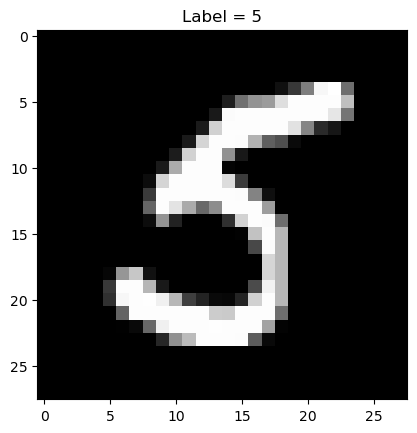

In [19]:
percentage_validation = 0.1 # Define percentage of images to use for validation
batch_size = 64 # Define batch size
train_loader, val_loader = load_mnist_training_validation(percentage_validation,batch_size)

# Example: Iterate through the data loader and get one batch of images and labels
img_idx = 54 # Can try any index between 0 and (batch_size-1) 
for images, labels in train_loader:
    print(f"Batch of images: {images.shape}")
    print(f"Batch of labels: {labels.shape}")
    image = images[img_idx,0,:,:]
    label = labels[img_idx]
    plt.imshow(image,cmap="gray")
    plt.title(f"Label = {label}")
    break  # Just to show one batch

### Task 3.2
The next step is to define a network for classification. You should define a PyTorch model that implements the following network:

![title](./img/simple_cnn.png)

Below is an example of how a simple PyTorch network can be defined. Use the PyTorch tutorials and documentation as a guide.

In [20]:
# Example, not intended to be used.
class simple_feedforward_network(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(simple_feedforward_network, self).__init__()
        # Defining the layers needed for the network
        self.fc1 = nn.Linear(input_size, hidden_size)  # First fully connected layer
        self.relu = nn.ReLU()  # ReLU activation
        self.fc2 = nn.Linear(hidden_size, output_size)  # Output layer
    
    def forward(self, x):
        # Defining the forward pass
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Apart from the layers used in the example above the functions `nn.Conv2d` and `nn.MaxPool2d` will be useful. Note that you have to set the stride for max pooling to 2 to get the expected downsampling. Your network can directly return the output from the final fully connected layer (the raw logits) since we will use the loss function `nn.CrossEntropyLoss` that internally applies the softmax operation to convert this to class probabilities.

You should fill in this template to design the asked for network.

In [24]:
class basic_cnn_classifier(nn.Module):
    def __init__(self):
        super(basic_cnn_classifier, self).__init__()

        # YOUR CODE HERE
        # 1. Convolutional Layer: 1 input channel, 25 output channels, 3x3 kernel
        self.conv = nn.Conv2d(in_channels=1, out_channels=25, kernel_size=3)
        
        # 2. Max Pooling Layer: 2x2 kernel
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 3. Fully Connected Layer: 10 output features
        # Math for input features:
        # - After 3x3 conv (no padding): 28x28 becomes 26x26
        # - After 2x2 max pool: 26x26 becomes 13x13
        # - Flattened size: 25 channels * 13 * 13 = 4225
        self.fc = nn.Linear(in_features=25 * 13 * 13, out_features=10)
        
    def forward(self, x):
        # YOUR CODE HERE
        # Apply conv -> relu -> maxpool
        x = self.pool(F.relu(self.conv(x)))
        
        # Flatten the tensor (batch_size, 25, 13, 13) -> (batch_size, 4225)
        x = x.view(-1, 25 * 13 * 13) # alternatively, you can use x = x.flatten(1)
        
        # Apply fully connected layer
        x = self.fc(x)
        
        return x
        


### Task 3.3
You should now train the network using the following training loop defined in `train_model`.

In [25]:
def train_model(
        model: torch.nn.Module, 
        train_loader: torch.utils.data.DataLoader, 
        test_loader: torch.utils.data.DataLoader, 
        num_epochs: int, 
        optimizer: torch.optim.Optimizer, 
        loss_fn: torch.nn.Module, 
        device: torch.device):
    
    """
    Trains the given model using the provided training and test data loaders, optimizer, and loss function for a specified number of epochs.
    
    Args:
        model (torch.nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
        num_epochs (int): Number of epochs to train the model.
        optimizer (torch.optim.Optimizer): The optimizer to use for training (e.g., Adam, SGD).
        loss_fn (torch.nn.Module): The loss function to use for training (e.g., CrossEntropyLoss).
        device (torch.device): The device to run the training on (e.g., 'cuda' or 'cpu').
    
    Returns:
        (torch.nn.Module): The trained model after the specified number of epochs.
    """
    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            # Move data to the correct device (GPU or CPU)
            inputs, targets = inputs.to(device), targets.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute the loss
            loss = loss_fn(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

        # Print the training statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

        # Validation loop (optional, to check model performance on validation data)
        model.eval()  # Set the model to evaluation mode
        val_correct = 0
        val_total = 0
        with torch.no_grad():  # Disable gradient calculation for validation
            for inputs, targets in tqdm(test_loader, desc="Validation", leave=False):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                val_total += targets.size(0)
                val_correct += (predicted == targets).sum().item()

        val_acc = 100 * val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.2f}%")

    print("Training complete.")
    return model

In [26]:
# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training loop
num_epochs = 5
lr = 0.001

# Initialize model, loss function, and optimizer
basic_model = basic_cnn_classifier().to(device)
loss_fn = nn.CrossEntropyLoss()  # Define the loss function

optimizer = optim.SGD(basic_model.parameters(), lr=lr)

basic_model_trained = train_model(basic_model, train_loader, val_loader, num_epochs, optimizer,loss_fn,device)

Using device: cpu


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch [1/5], Loss: 0.8348, Accuracy: 81.43%


Training:  20%|██        | 1/5 [00:06<00:26,  6.62s/it]

Validation Accuracy: 88.18%
Epoch [2/5], Loss: 0.4045, Accuracy: 89.20%


...

Validation Accuracy: 90.75%
Epoch [4/5], Loss: 0.3150, Accuracy: 91.08%


Training:  80%|████████  | 4/5 [00:25<00:06,  6.47s/it]

Validation Accuracy: 91.20%
Epoch [5/5], Loss: 0.2964, Accuracy: 91.60%


Training: 100%|██████████| 5/5 [00:32<00:00,  6.57s/it]

Validation Accuracy: 91.68%
Training complete.


### Task 3.4
Work out how many trainable parameters your network contains. Note that the convolution layer does not use padding so the output from the convolution layer is smaller than the input.

**Your answer:**
The network contains a total of 42,510 trainable parameters. 

1. Convolutional Layer
- Weights: 25 filters $\times$ 1 input channel $\times$ (3 $\times$ 3 kernel size) = 225 parameters 
- Biases: 25 filters $\times$ 1 bias term per filter = 25 parameters 
- Total for Conv layer: 225 + 25 = 250 parameters

2. Max Pooling Layer
- Max pooling is simply a mathematical operation that takes the maximum value in a window. It has no learned weights or biases. 
- Total for Pooling layer:0 parameters

3. Fully Connected Layer
- Weights: 4,225 input features $\times$ 10 output features = 42,250 parameters 
- Biases: 10 output classes $\times$ 1 bias term per class = 10 parameters 
- Total for FC layer: 42,250 + 10 = 42,260 parameters

Total Network Parameters:
250 + 0 + 42,260 = 42,510 parameters


### Task 3.5
To run a convolutional neural network we have to perform a massive amount of computations. Hence it is very important to consider the computational load when designing a network. For the network below, compare (roughly) the time consumption (number of computations required) for the blue and the red layers. You can ignore effects of padding. NOTE: You are not supposed to actually implement and train this network.


![title](img/blue_red_cnn.PNG)

**Your answer:** 

The number of computations in a convolutional layer = `(Input Channels) × (Output Channels) × (Kernel Height × Kernel Width) × (Output Feature Map Area)`

Let the spatial resolution of the feature map entering the blue layer be $A$.

 1. Blue Layer (`10 conv 5x5`)
- Input Channels: 10 (coming from the very first `10 conv 5x5` layer)
- Output Channels: 10
- Kernel Size: $5 \times 5 = 25$
- Feature Map Area: $A$ 
- Total Computations: $10 \times 10 \times 25 \times A = \mathbf{2,500 \times A}$

2. Red Layer (`20 conv 5x5`)
- The first max pool cuts height and width in half, reducing the area to $\frac{A}{4}$.
- The second max pool cuts them in half again, reducing the area to $\frac{A}{16}$.
- The layer immediately preceding the red layer is a `10 conv 5x5`, so the input channels remain 10.
- Input Channels: 10
- Output Channels: 20
- Kernel Size: $5 \times 5 = 25$
- Feature Map Area: $\frac{A}{16}$
- Total Computations: $10 \times 20 \times 25 \times \left(\frac{A}{16}\right) = 5000 \times \frac{A}{16} = \mathbf{312.5 \times A}$

3. Conclusion Comparison
$$ \frac{\text{Blue Layer Computations}}{\text{Red Layer Computations}} = \frac{2500 \times A}{312.5 \times A} = \mathbf{8} $$

**Summary:** The Blue layer requires 8 times as many computations as the Red layer. 
Even though the Red layer has twice as many filters (20 vs 10) and doubles the channel-based calculations, the spatial resolution of the feature maps has been drastically reduced by a factor of 16 due to the pooling layers, making the earlier layer much heavier to compute.



### Task 3.6

Imagine that the blue box of the network in the figure above is replaced by a sequence of two layers of 10 3 × 3 convolutional filters. What changes in terms of network parameters, time consumption (number of computations) and accuracy would that lead to?


**Your answer:** 

1. Network Parameters:
- Original ($1 \times 5 \times 5$ layer):
    - 10 input channels $\times$ 10 output channels $\times$ (5 $\times$ 5) + 10 biases = 2,510 total parameters
- New ($2 \times 3 \times 3$ layers):
    - Layer 1: 10 input $\times$ 10 output $\times$ (3 $\times$ 3) = 900 weights + 10 biases = 910 parameters
    - Total: 910 $\times$ 2 layers = 1,820 total parameters
- The number of parameters decreases by from 2510 to 1820.

2. Time Consumption (Computations): 
- Original Original ($1 \times 5 \times 5$ layer):
    - 10 in $\times$ 10 out $\times$ 25 (kernel area) $\times$ $A$ = 2,500 $\times$ $A$ operations
- New ($2 \times 3 \times 3$ layers):
    - Layer 1: 10 in $\times$ 10 out $\times$ 9 (kernel area) $\times$ $A$ = $900 \times A$
    - Layer 2: 10 in $\times$ 10 out $\times$ 9 (kernel area) $\times$ $A$ = $900 \times A$
    - Total: 1,800 $\times$ $A$ operations
- The computational load decreases by 28% (from 2500A to 1800A), leading to faster training and inference.

3. Accuracy:
- Receptive Field: Two stacked $3 \times 3$ filters have an effective "receptive field" of $5 \times 5$ on the input image. This means they look at the exact same spatial area as one $5 \times 5$ filter. No spatial context is lost.
- Non-linearity: By splitting it into two layers, you typically insert an activation function (like ReLU) between them. This adds an extra layer of non-linearity to the network.
- Result: The network becomes deeper and can learn more complex functions while looking at the exact same size patch of the image. Consequently, the accuracy is expected to increase.



### Task 3.7
Make a copy of `basic_cnn_classifier` and name it `better_cnn_classifier`. Try modifying the network by adding more layers. Also experiment with the training options. How much can you improve the results?

In [ ]:
class better_cnn_classifier(nn.Module):
    def __init__(self):
        super(better_cnn_classifier, self).__init__()

        # YOUR CODE HERE
        # Define the layers needed for your network
        # First layer of convolution: 1 -> 32 channels
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Second layer of convolution: 32 -> 64 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout: Randomly deactivate 25% of neurons to prevent overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # Fully connected layer
        # MNIST 28x28 becomes 7x7 after two 2x2 poolings
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)


    def forward(self, x):
        # Your code here
        # First block: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # Second block: Conv -> BN -> ReLU -> Pool -> Dropout
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        
        # Leveling into the fully connected layer
        x = x.view(-1, 64 * 7 * 7)
        
        # Fully connected layer 1 -> Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        
        # output layer
        x = self.fc2(x)
        return x

In [28]:
# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training loop
num_epochs = 5
lr = 0.001

# Initialize model, loss function, and optimizer
better_model = better_cnn_classifier().to(device)
loss_fn = nn.CrossEntropyLoss()  # Define the loss function
optimizer = optim.SGD(better_model.parameters(), lr=lr)

better_model_trained = train_model(better_model, train_loader, val_loader, num_epochs, optimizer,loss_fn,device)

Using device: cpu


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch [1/5], Loss: 1.1648, Accuracy: 67.43%


Training:  20%|██        | 1/5 [00:24<01:37, 24.26s/it]

Validation Accuracy: 90.48%
Epoch [2/5], Loss: 0.4652, Accuracy: 87.36%


...

Validation Accuracy: 94.68%
Epoch [4/5], Loss: 0.2680, Accuracy: 92.48%


Training:  80%|████████  | 4/5 [01:32<00:23, 23.14s/it]

Validation Accuracy: 95.62%
Epoch [5/5], Loss: 0.2289, Accuracy: 93.55%


Training: 100%|██████████| 5/5 [01:55<00:00, 23.13s/it]

Validation Accuracy: 95.98%
Training complete.


### Task 3.8
You should now take your model that gave best results on the validation set and evaluate it on the test set. Compute precision and recall for each of the 10 classes. 

In [ ]:
def precision(labels: np.ndarray, predicted_labels: np.ndarray,class_label: int) -> float:
    """
    Computes the precision of the classifier.
    
    Args:
        labels: true labels (shape (N,))
        predicted_labels: predicted labels (shape (N,))
    
    Returns:
        precision: Precision of the classifier as a percentage
    """
    # YOUR CODE HERE
    # TP: predicted to be class_label and true to be class_labelrue to be class_label
    tp = np.sum((labels == class_label) & (predicted_labels == class_label))
    # FP: Predicted as class_label but actual not class_label
    fp = np.sum((labels != class_label) & (predicted_labels == class_label))
    
    if (tp + fp) == 0:
        return 0.0
    return 100.0 * tp / (tp + fp)

def recall(labels: np.ndarray, predicted_labels: np.ndarray,class_label: int) -> float:
    """
    Computes the recall of the classifier.
    
    Args:
        labels: true labels (shape (N,))
        predicted_labels: predicted labels (shape (N,))
    
    Returns:
        recall: Recall of the classifier as a percentage
    """
    # YOUR CODE HERE
    # TP: predicted to be class_label and true to be class_label
    tp = np.sum((labels == class_label) & (predicted_labels == class_label))
    # FN: Prediction is not class_label but reality is class_label
    fn = np.sum((labels == class_label) & (predicted_labels != class_label))
    
    if (tp + fn) == 0:
        return 0.0
    return 100.0 * tp / (tp + fn)

def metrics_on_test_set(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, device: torch.device) -> Dict[int, Dict[str, float]]:
    """
    Evaluates the model on the test set and computes precision and recall.
    
    Args:
        model (torch.nn.Module): The trained model to be evaluated.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
        device (torch.device): The device to run the evaluation on (e.g., 'cuda' or 'cpu').
    Returns:
        metrics: A dictionary containing precision and recall for each class with structure {class_label: {'precision': value, 'recall': value}}
    """
    # YOUR CODE HERE
    model.eval() # Switch to evaluation mode
    all_labels = []
    all_preds = []
    
    with torch.no_grad(): # Gradient is not calculated during testing
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(targets.numpy())
            all_preds.extend(predicted.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    metrics = {}
    for cls in range(10): # Calculate the indicator for each number 0-9
        p = precision(all_labels, all_preds, cls)
        r = recall(all_labels, all_preds, cls)
        metrics[cls] = {'precision': p, 'recall': r}
        
    return metrics


In [30]:
test_loader = load_mnist_test(batch_size=64)

# Evaluate the better model on the test set
test_metrics = metrics_on_test_set(better_model_trained, test_loader, device)
print("Test Metrics (Precision and Recall for each class):")
for cls, metric in test_metrics.items():
    print(f"Class {cls}: Precision = {metric['precision']:.2f}%, Recall = {metric['recall']:.2f}%")

Test Metrics (Precision and Recall for each class):
Class 0: Precision = 96.31%, Recall = 98.67%
Class 1: Precision = 97.82%, Recall = 99.03%
Class 2: Precision = 95.58%, Recall = 94.28%
Class 3: Precision = 96.44%, Recall = 96.44%
Class 4: Precision = 97.35%, Recall = 97.35%
Class 5: Precision = 95.27%, Recall = 97.09%
Class 6: Precision = 96.87%, Recall = 96.76%
Class 7: Precision = 96.40%, Recall = 93.87%
Class 8: Precision = 94.94%, Recall = 94.46%
Class 9: Precision = 95.20%, Recall = 94.45%


### Task 3.9
Plot three images where your model fails with names indicating what digit they were mistaken for and what is the true class. Have a look at the images before submitting it, so it looks right.

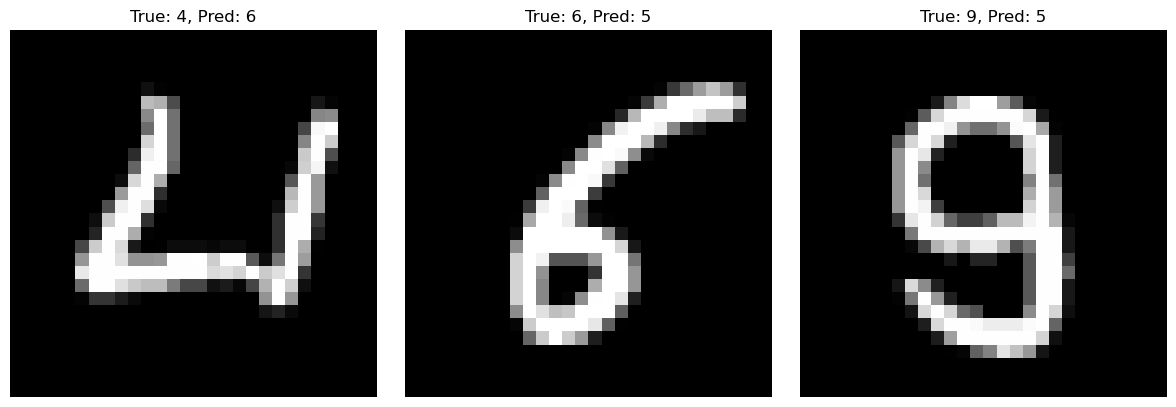

In [ ]:
# YOUR CODE HERE
def plot_misclassified(model, test_loader, device, num_images=3):
    model.eval()
    failed_images = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            # Find the index of prediction error
            incorrect_idx = (predicted != targets).nonzero(as_tuple=True)[0]
            
            for idx in incorrect_idx:
                img = inputs[idx].cpu().squeeze().numpy()
                true_label = targets[idx].item()
                pred_label = predicted[idx].item()
                failed_images.append((img, true_label, pred_label))
                
                if len(failed_images) >= num_images:
                    break
            if len(failed_images) >= num_images:
                break

    # Drawing
    plt.figure(figsize=(12, 4))
    for i, (img, true, pred) in enumerate(failed_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true}, Pred: {pred}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call function to display failure case
plot_misclassified(better_model_trained, test_loader, device)
